# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel. 

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


--- 
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [3]:
# importar librerías
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [4]:
# cargar archivos
plans = pd.read_csv("/datasets/plans.csv")
users = pd.read_csv("/datasets/users_latam.csv")
usage = pd.read_csv("/datasets/usage.csv")

In [5]:
#mostrar las primeras 5 filas de plans
plans.head(5)

,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [6]:
# mostrar las primeras 5 filas de users
users.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [7]:
# mostrar las primeras 5 filas de usage
usage.head(5)

,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


**Tip:** Si no usas `print()` la tabla se vera mejor.

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [8]:
# revisar el número de filas y columnas de cada dataset
print("plans", plans.shape)
print("users", users.shape)
print("usage", usage.shape)

plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [9]:
# inspección de plans con .info()
plans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


In [10]:
# inspección de users con .info()
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [11]:
# inspección de usage con .info()
usage.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [12]:
# cantidad de nulos para users

# Cantidad de valores nulos
print("Cantidad de valores nulos")
print(users.isna().sum())
print()
# Proporción de valores nulos
print("Proporción de valores nulos")
print(users.isna().mean())

Cantidad de valores nulos
user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    3534
dtype: int64

Proporción de valores nulos
user_id       0.00000
first_name    0.00000
last_name     0.00000
age           0.00000
city          0.11725
reg_date      0.00000
plan          0.00000
churn_date    0.88350
dtype: float64


In [13]:
# cantidad de nulos para usage
print ("Cantidad de valores nulos")
print(usage.isna().sum())
print("")
print("Proporción de valores nulos")
print(usage.isna().mean())

Cantidad de valores nulos
id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64

Proporción de valores nulos
id          0.00000
user_id     0.00000
type        0.00000
date        0.00125
duration    0.55190
length      0.44740
dtype: float64


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico al final del bloque. Incluye qué ves y que acción recomendarías para cada caso.

💡 **Nota:** Justifica tus decisiones brevemente (1 línea por caso).
* Hint:
 - Si una columna tiene **más del 80–90% de nulos**, normalmente se **ignora o elimina**.  
 - Si tiene **entre 5% y 30%**, generalmente se **investiga para imputar o dejar como nulos**.  
 - Si es **menor al 5%**, suele ser un caso simple de imputación o dejar como nulos. 
 
 ---

**Valores nulos**  
- ¿Qué columnas tienen valores faltantes y en qué proporción?
- Indica qué harías: ¿imputar, eliminar, ignorar?

Para el caso de usuarios:
    - Tenemos la columna de city con un 11% de valores nulos, por lo cual recomendaria que se dejarán de esta manera a menos que sea necesario segmentar a los clientes por ciudad          entonces tendriamos que indagar un poco más, si no es necesario segmentar por esta columna se dejaría de esta manera.
    - Y tenemos también la columna de churn_date con un 88% de información nula lo cual parece correcto puesto que la mayoria de la informacion es de clientes activos, esta columna        definitivamente se queda así.

Para el caso de la tabla de usage:
    - Tenemos tenemos la columna de date con .25% de nulos, la muestra es muy pequeña por lo cual recomiendo dejarla de esta manera.
    - Tenemos también la columna de duration con un 55%  y de lenght con un 44% de nulos, en este caso recomendaria verificar si la perdida de información esta ligada a otra columna        antes de tomar una decisión.
    


### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [14]:
# explorar columnas numéricas de users
#users.info()
columnas_numericas_users = ["user_id","age"]
print("metricas")
print(users[columnas_numericas_users].describe())
print()
print("mediana")
print(users[columnas_numericas_users].median())
print()
print("valores nulos")
print(users[columnas_numericas_users].isna().sum())


metricas
            user_id          age
count   4000.000000  4000.000000
mean   11999.500000    33.739750
std     1154.844867   123.232257
min    10000.000000  -999.000000
25%    10999.750000    32.000000
50%    11999.500000    47.000000
75%    12999.250000    63.000000
max    13999.000000    79.000000

mediana
user_id    11999.5
age           47.0
dtype: float64

valores nulos
user_id    0
age        0
dtype: int64


- La columna `user_id` se refiere al identificador de los usuarios, podemos ver que tenemos 4000 usuarios, que la numeración empieza en 10000 y el valor máximo es 13999 , es decir fueron generados de manera secuencial.
- La columna `age` ... En age se refiere a la edad de los usuarios, aquí vemos un problema porque tenemos como valor minimo -999 que es un valor negativo y nadie puede tener esa edad, por lo que hace que nuestra media se recorra y quede en 33.73 cuando nuestra mediana es más confiable con un valor de 47, podemos decir que nuestra desviación esta sesgada a la izquierda por ese o esos valores negativos, por lo que hay que revisar esta información, pero se recomendaría usar la mediana ya que la medía esta sesgada por el valor fuera de rango.

In [15]:
# explorar columnas numéricas de usage
#usage.info()
columnas_numericas_usage = ["id", "user_id","duration","length"]
print("metricas")
print(usage[columnas_numericas_usage].describe())
print()
print("mediana")
print(usage[columnas_numericas_usage].median())
print()
print("valores vacios")
print(usage[columnas_numericas_usage].isna().sum())
print()
print("promedio de valores vacios")
print(usage[columnas_numericas_usage].isna().mean())

metricas
                id       user_id      duration        length
count  40000.00000  40000.000000  17924.000000  22104.000000
mean   20000.50000  12002.405975      5.202237     52.127398
std    11547.14972   1157.279564      6.842701     56.611183
min        1.00000  10000.000000      0.000000      0.000000
25%    10000.75000  10996.000000      1.437500     37.000000
50%    20000.50000  12013.000000      3.500000     50.000000
75%    30000.25000  13005.000000      6.990000     64.000000
max    40000.00000  13999.000000    120.000000   1490.000000

mediana
id          20000.5
user_id     12013.0
duration        3.5
length         50.0
dtype: float64

valores vacios
id              0
user_id         0
duration    22076
length      17896
dtype: int64

promedio de valores vacios
id          0.0000
user_id     0.0000
duration    0.5519
length      0.4474
dtype: float64


- La columna `id` Parece ser el identificador del registro de la tabla usage, por lo que nos infica que tiene exactamente 40 000 registros, el id empezó en 1 el id máximo es 40 000, es decir fue avanzando de manera secuencial
- La columna `user_id` es el identificar foraneo de la tabla de users, nos indica que hat 40 000 registros en total, su valor minimo y máximo concuerdan con la tabla de users.
- Las columnas "duration" tiene registros faltantes, su media no coincide con la mediana, y tiene un 55% de registros vacios
- La columna "lenght" también tiene registros faltantes , pero no coindiciden con la cantidad de rgitros de la columna de duration, su media y mediana son muy cercanas por lo que no consideramos que haya outliner singnificativos y tenemos un 44% de información faltante.

In [16]:
# explorar columnas categóricas de users
columnas_user = ['city', 'plan']
print("metricas")
print(users[columnas_user].describe())
print()
print("mediana")
print(users[columnas_user].mean())
print()
print("Número de valores faltantes")
print(users[columnas_user].isna().sum())
print()
print("Porcentaje de valores faltantes")
print(users[columnas_user].isna().mean())


metricas
          city    plan
count     3531    4000
unique       7       2
top     Bogotá  Basico
freq       808    2595

mediana
Series([], dtype: float64)

Número de valores faltantes
city    469
plan      0
dtype: int64

Porcentaje de valores faltantes
city    0.11725
plan    0.00000
dtype: float64


- La columna `city` contiene 3531 valores por lo que consideramos que falta información en esa columna, también vemos que tenemos 7 ciudades diferentes donde Bógota es el registro con más frecuencia, tenemos un porcentaje de 11% de valores faltantes
- La columna `plan` contiene 4000 registros por lo que esta completo sin valores faltantes, contiene solamente dos categorias lo cual es correcto puesto que la tabla de planes solo tiene dos opciones, y el plan más popular es el básico con 2595 registros

In [17]:
# explorar columna categórica de usage
print(usage['type'].describe())
print(usage['type'].head())
print(usage['type'].unique())
print(usage['type'].isna().sum())


count     40000
unique        2
top        text
freq      22092
Name: type, dtype: object
0    call
1    text
2    text
3    call
4    call
Name: type, dtype: object
['call' 'text']
0


In [18]:
# sentinel
print(users["city"].unique())
print(users["plan"].unique())
print(usage["type"].unique())

['Medellín' '?' 'CDMX' 'Bogotá' 'GDL' 'MTY' nan 'Cali']
['Basico' 'Premium']
['call' 'text']


- La columna `type` ... es una columna de categorias, que esta completa, contiene dos categorias (call o text). el texto más frecuente es text con una frecuencia de 22 092 registros con ese texto


---
✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico. Incluye qué ves y que acción recomendarías para cada caso. 

**Valores inválidos o sentinels**  
- ¿En qué columnas encontraste valores inválidos o sentinels?  
- ¿Qué acción tomarías?


Hay valores invalidos en la columna de city, por el momento vamos a dejarla así a menos de que tengamos que segmentar por ciudad, entonces vamos a cancelar los valores <NA> Y nan para dejarlos como nulos




### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [19]:
# Convertir a fecha la columna `reg_date` de users
users['reg_date'] = pd.to_datetime(users['reg_date'],errors = "coerce")


In [20]:
# Convertir a fecha la columna `date` de usage
usage['date'] = pd.to_datetime(usage['date'], errors = "coerce")



In [21]:
# Revisar los años presentes en `reg_date` de users
print(users['reg_date'].dt.year.value_counts())
print(users['reg_date'].dt.year.unique())
print (users['reg_date'].dt.year.isna().mean())

2024    1330
2023    1316
2022    1314
2026      40
Name: reg_date, dtype: int64
[2022 2026 2023 2024]
0.0


En `reg_date`, tiene valores invalidos del año 2026

In [22]:
# Revisar los años presentes en `date` de usage
print (usage['date'].dt.year.value_counts())
print (usage['date'].dt.year.unique())
print (usage['date'].dt.year.isna().mean())


2024.0    39950
Name: date, dtype: int64
[2024.   nan]
0.00125


En `date`, todos los registros pertenecen al año 2024, no hay información del 2023,2022 y 2026 como en la tabla de usuarios 
Basaremos el análisis en estas fechas.

✍️ **Comentario**: escribe tu diagnóstico, e incluye **qué acción recomendarías** para cada caso:

**Fechas fuera de rango**  
- ¿Aparecen años imposibles? (años muy viejos o sin transcurrir al momento de guardar los datos)
- ¿Qué harías con ellas?

En la tabla de usuarios tenemos en año 2024 y  2023,2022 que no vamos  a usar, también tenemos valores imposibles del añio 2026 y  valores nulos, los valores nulos son una muestra muy pequeña por lo cual la vamos a ignorar.

En la tabla de usage toda la información pertenece al año 2024 lo que es correcto y una muestra muy pequeña devalores nulos que vamos a dejar así. 

---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [23]:
# Reemplazar -999 por la mediana de age
print("media:",users["age"].mean())
print("mediana:",users["age"].median())
print("?",users["age"].isin(["?"]).sum())
print("-999",users["age"].isin([-999]).sum())
print("le:",users["age"].le(0).sum())
print("media de -999:",users["age"].isin([-999]).mean())
#print(users[users["age"].isin([-999])])
age_mediana = users["age"].median()
users['age'] = users['age'].replace([-999],age_mediana)
# Verificar cambios
users['age'].describe()

media: 33.73975
mediana: 47.0
? 0
-999 55
le: 55
media de -999: 0.01375


count    4000.000000
mean       48.122250
std        17.690408
min        18.000000
25%        33.000000
50%        47.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

In [24]:
# Reemplazar ? por NA en city
users["city"] = users["city"].replace("?", pd.NA)
# Verificar cambios
print(users["city"].isin(["?"]).sum())




0


In [25]:
# Marcar fechas futuras como NA para reg_date
#print(users[users["reg_date"].dt.year == 2026])
#print(users[users["reg_date"].dt.year == 2026].count())
users["reg_date"] = users["reg_date"].where(users["reg_date"].dt.year != 2026, pd.NaT)
#users.head()
# Verificar cambios
print(users[users["reg_date"].dt.year == 2026].count())


user_id       0
first_name    0
last_name     0
age           0
city          0
reg_date      0
plan          0
churn_date    0
dtype: int64


### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [26]:
# Verificación MAR en usage (Missing At Random) para duration
print("suma: ",usage["duration"].isna().sum())
print()
print("promedio duration: ")
print(usage["duration"].isna().groupby(usage["type"]).mean())
print()
print("suma por tipo: ")
print(usage["duration"].isna().groupby(usage["type"]).sum())


suma:  22076

promedio duration: 
type
call    0.000000
text    0.999276
Name: duration, dtype: float64

suma por tipo: 
type
call        0
text    22076
Name: duration, dtype: int64


In [27]:
# Verificación MAR en usage (Missing At Random) para duration
print("suma: ",usage["length"].isna().sum())
print()
print("promedio: ")
print(usage["length"].isna().groupby(usage["type"]).mean())
print()
print("suma por tipo: ")
print(usage["length"].isna().groupby(usage["type"]).sum())


suma:  17896

promedio: 
type
call    0.99933
text    0.00000
Name: length, dtype: float64

suma por tipo: 
type
call    17896
text        0
Name: length, dtype: int64


Haz doble clic aquíy escribe que tu diagnostico de nulos en `duration` y `length`:
es un MAR (Missing at Random) faltan siguiendo un patrón externo que depende del campo type 
Al parecer solo vamos a tener información de duration y lenght cuando el tipo sea una llamada lo cual le da sentido a la información puesto que cuando es un mensaje de texto no tenemos duración de la llamada ni longitud.


---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico. 

**Instrucciones:**: 
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.

In [28]:
usage.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   id        40000 non-null  int64         
 1   user_id   40000 non-null  int64         
 2   type      40000 non-null  object        
 3   date      39950 non-null  datetime64[ns]
 4   duration  17924 non-null  float64       
 5   length    22104 non-null  float64       
dtypes: datetime64[ns](1), float64(2), int64(2), object(1)
memory usage: 1.8+ MB


In [29]:

# Columnas auxiliares
usage["is_text"] = (usage["type"] == "text").astype(int) #conocer el total de mensajes
usage["is_call"] = (usage["type"] == "call").astype(int) #conocer el total de llamadas

#column_new = ["is_text","is_call", "duration" ]
#column_clean = ["user_id","is_text","is_call", "duration" ]
#usage_clean = usage[column_clean]

#print(usage[usage["user_id" ]== 10000])
#print(usage_clean)
# Agrupar información por usuario
#usage_agg = usage ... reset_index()
usage_agg  = usage.groupby ("user_id")["duration","is_text","is_call"].sum().reset_index()

# Renombrar columnas
usage_agg = usage_agg.rename (columns = {"is_text": "cant_mensajes", "is_call": "cant_llamadas", "duration": "cant_minutos_llamada"})

# observar resultado
usage_agg.head(3)

,user_id,cant_minutos_llamada,cant_mensajes,cant_llamadas
0,10000,23.70,7,3
1,10001,33.18,5,10
2,10002,10.74,5,2


In [30]:
# Combinar la tabla agregada con el dataset de usuarios
user_profile = pd.merge(usage_agg,users, on = "user_id", how = "inner")
user_profile.head(20)

,user_id,cant_minutos_llamada,cant_mensajes,cant_llamadas,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,23.70,7,3,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,33.18,5,10,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,10.74,5,2,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,8.99,11,3,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,8.01,4,3,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN
5,10005,44.97,5,7,Luis,Garcia,61.0,MTY,2022-01-02 08:51:29.572393098,Basico,NaN
6,10006,28.39,3,5,Sofia,Lopez,39.0,Bogotá,2022-01-02 15:25:47.486871717,Basico,NaN
7,10007,30.23,3,5,Sofia,Gomez,70.0,Medellín,2022-01-02 22:00:05.401350337,Premium,NaN
8,10008,28.85,5,5,Sofia,Garcia,76.0,CDMX,2022-01-03 04:34:23.315828957,Basico,NaN
9,10009,5.99,5,3,Mateo,Torres,47.0,Bogotá,2022-01-03 11:08:41.230307576,Basico,NaN


### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.

In [31]:
user_profile.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 3999 entries, 0 to 3998
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   user_id               3999 non-null   int64         
 1   cant_minutos_llamada  3999 non-null   float64       
 2   cant_mensajes         3999 non-null   int64         
 3   cant_llamadas         3999 non-null   int64         
 4   first_name            3999 non-null   object        
 5   last_name             3999 non-null   object        
 6   age                   3999 non-null   float64       
 7   city                  3434 non-null   object        
 8   reg_date              3959 non-null   datetime64[ns]
 9   plan                  3999 non-null   object        
 10  churn_date            466 non-null    object        
dtypes: datetime64[ns](1), float64(2), int64(3), object(5)
memory usage: 374.9+ KB


In [32]:
# Resumen estadístico de las columnas numéricas
user_profile = user_profile[user_profile["reg_date"].dt.year== 2024]
#user_profile[{"cant_minutos_llamada", "cant_mensajes", "cant_llamadas", "age"}].agg(["mean","median","min","max"])
user_profile[{"cant_minutos_llamada", "cant_mensajes", "cant_llamadas", "age"}].describe()



,cant_mensajes,age,cant_llamadas,cant_minutos_llamada
count,1330.000000,1330.000000,1330.000000,1330.000000
mean,5.500000,48.414286,4.557143,24.126669
std,2.382293,17.963443,2.140329,19.458620
min,0.000000,18.000000,0.000000,0.000000
25%,4.000000,33.000000,3.000000,11.332500
50%,5.000000,48.000000,4.000000,20.325000
75%,7.000000,64.000000,6.000000,32.542500
max,16.000000,79.000000,13.000000,155.690000


In [33]:
# Distribución porcentual del tipo de plan
#user_profile["plan"].describe()
user_profile["plan"].value_counts(normalize = True) * 100



Basico     65.639098
Premium    34.360902
Name: plan, dtype: float64

---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada` 

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda) 

**Hint**  
Para cada histograma, 
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

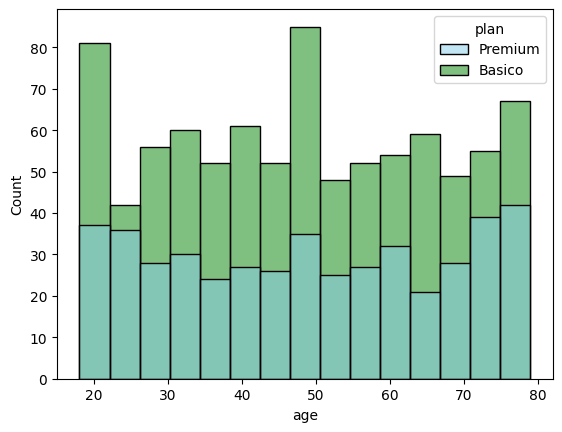

In [34]:
# Histograma para visualizar la edad (age)
#sns.histplot(...)
#plt.show()

sns.histplot(data = user_profile, x= user_profile["age"] ,bins = 15, hue = "plan", palette = ["skyblue","green"])
plt.show()



In [35]:
data = user_profile.groupby(["plan", "age"])["age"].count()
print(data)

plan     age 
Basico   18.0    20
         19.0     9
         20.0    19
         21.0    19
         22.0    14
                 ..
Premium  75.0     6
         76.0    11
         77.0     9
         78.0    14
         79.0     2
Name: age, Length: 124, dtype: int64


💡Insights: 
- Distribución ...
- La ditribución para ambos planes se ve uniforme e excepcion de una clara tebdencia en los 25 años aprox en donde vemos una tendencia por usar el plan premium, así como una tendencia despues de los 70 a usar premium.
- Yo veo una distribución simetrica.

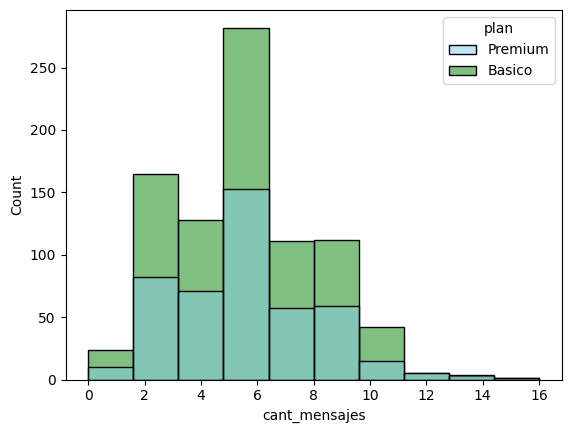

In [36]:
# Histograma para visualizar la cant_mensajes
sns.histplot(data = user_profile, x= user_profile["cant_mensajes"] ,bins = 10, hue = "plan", palette = ["skyblue","green"])
plt.show()



💡Insights: 
- Los usuarios del plan básico como del premium tienden a enviar una cantidad baja de mensajes, siendo la más frecuente enree 5 y 6 mensajes.
- No se observan diferencias importantes entre ambos planes, por lo que no se considera que exista un patrón claro que relacione la cantidad de mensajes enviados con el tipo de plan contratado.
- La distribución presenta un sesgo a la derecha, con unos pocos usuarios con cantiades arriba de 10, considerablemente mayores al promedio. 


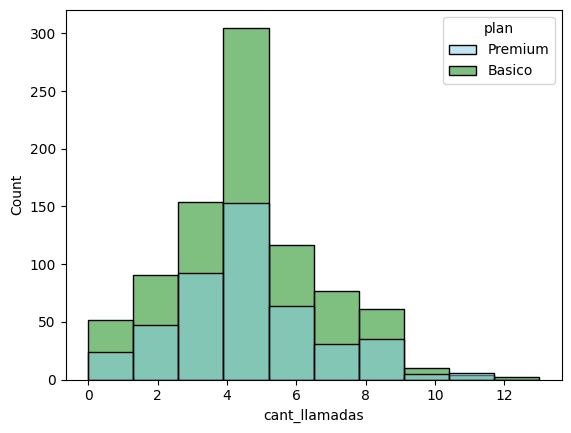

In [37]:
# Histograma para visualizar la cant_llamadas
sns.histplot(data = user_profile, x= user_profile["cant_llamadas"] ,bins = 10, hue = "plan", palette = ["skyblue","green"])
plt.show()


💡Insights: 
- Distribución ...
- Los usuarios de los planes básico y premium tienden a realizar entre 4 y 5 llamadas.
- Ambos planes muestran un comportamiento muy similar, por lo que no se observa un patrón claro que diferencie a los usuarios según la cantidad de llamadas realizadas.
- La distribución presenta un sesgo a la derecha, debido a la presencia de pocos usuarios con una cantidad de llamadas mayores al promedio.

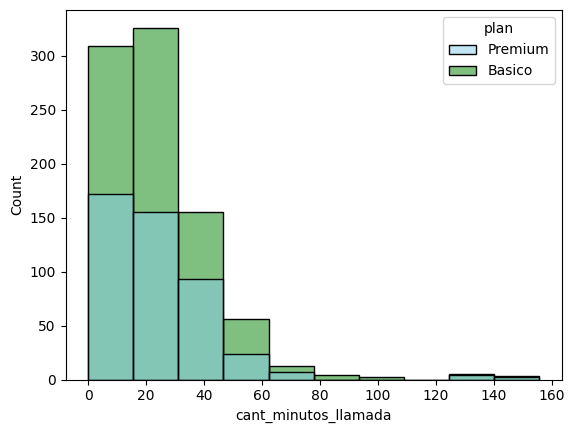

In [38]:
# Histograma para visualizar la cant_minutos_llamada
sns.histplot(data = user_profile, x= user_profile["cant_minutos_llamada"] ,bins = 10, hue = "plan", palette = ["skyblue","green"])
plt.show()

💡Insights: 
- Los usuarios de los planes básico y premium tienden a usar sus minutos de llamada entre 0 y 30 minutos. A medida que aumenta la duración de las llamadas, la cantidad de usuarios disminuye considerablemente.
- No se observan diferencias importantes entre ambos planes.
- La distribución presenta un sesgo pronunciado a la derecha, debido a la presencia de usuarios con cantidades altas de minutos en llamadas.
-  

### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age` 
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>


- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.


**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

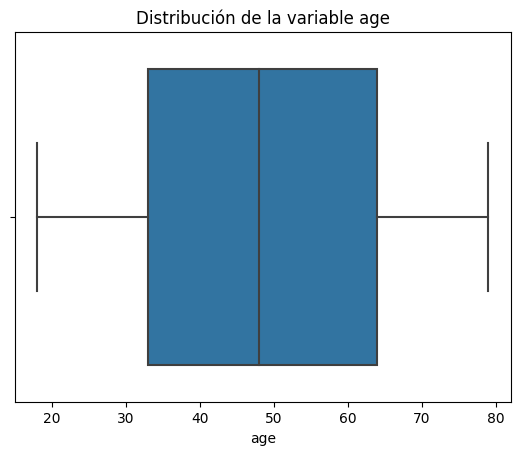

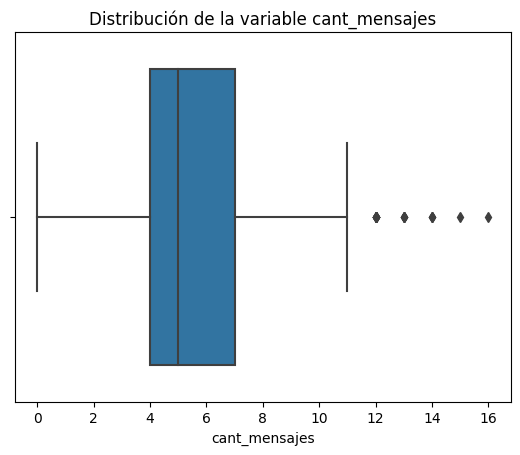

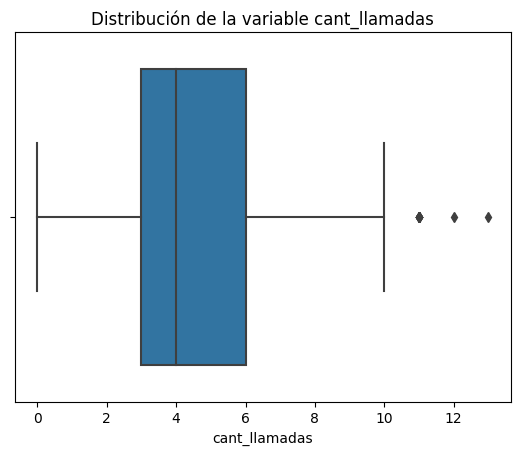

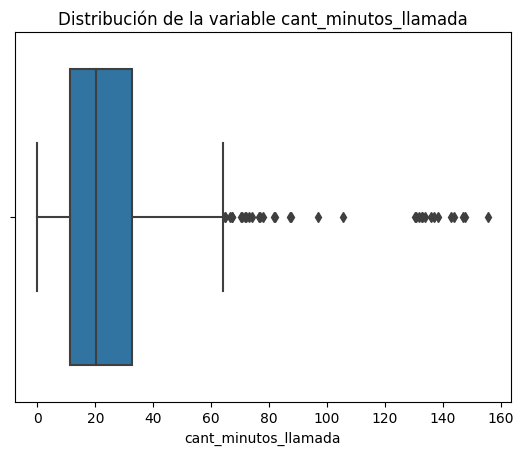

In [39]:
# Visualizando usando BoxPlot 
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']


for col in columnas_numericas:
    sns.boxplot (x = user_profile[col])
    plt.title (f"Distribución de la variable {col}")
    plt.show()


💡Insights: 
- Age: ...no presenta outliers
- cant_mensajes: presenta outliers
- cant_llamadas: presenta outliers
- cant_minutos_llamada: presenta outliers

In [40]:
# Calcular límites con el método IQR
columnas_limites = ["cant_mensajes","cant_llamadas","cant_minutos_llamada"]
for col in columnas_limites:
    Q1 = user_profile[col].quantile(0.25)
    Q3= user_profile[col].quantile(0.75)
    IQR = Q3 - Q1
    upper = Q3 + 1.5*IQR
    print ("IQR de " ,col,"", IQR)
    print ("upper de " ,col,"", upper)
    
    
    
    



IQR de  cant_mensajes  3.0
upper de  cant_mensajes  11.5
IQR de  cant_llamadas  3.0
upper de  cant_llamadas  10.5
IQR de  cant_minutos_llamada  21.209999999999997
upper de  cant_minutos_llamada  64.35749999999999


In [41]:
# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
print(user_profile[columnas_limites].describe())
print(user_profile[columnas_limites].median())

       cant_mensajes  cant_llamadas  cant_minutos_llamada
count    1330.000000    1330.000000           1330.000000
mean        5.500000       4.557143             24.126669
std         2.382293       2.140329             19.458620
min         0.000000       0.000000              0.000000
25%         4.000000       3.000000             11.332500
50%         5.000000       4.000000             20.325000
75%         7.000000       6.000000             32.542500
max        16.000000      13.000000            155.690000
cant_mensajes            5.000
cant_llamadas            4.000
cant_minutos_llamada    20.325
dtype: float64


💡Insights: 
- cant_mensajes: mantener o no outliers, porqué? vamos a mantener los outliners, puesto que la medía esta en 5.5 y la mediana en 5 por lo que no recorre significativamente el valor los outliners y nos puede servir esta información.
- cant_llamadas: mantener o no outliers, porqué?  La medía es de 1.55 y la mediana de 4, osea que el valor de la mediana no se recorre demasiado, el valor máximo es 13 y nuestro upper es de 10.5, no esta muy alejado.
- cant_minutos_llamada: mantener o no outliers, porqué? Nuestra media es de 24 y la mediana es de 20, nuestro valor upper es de 64 y el máximo es de 155 , nuestra desviación estandar es alta de 24, por lo que valdría la pena una revision adicional para ver su naturaleza y decidir si estos valores merecen conservarse.

---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [42]:
# Crear columna grupo_uso

def clasificar (row):
    llamadas = row["cant_llamadas"]
    mensajes = row["cant_mensajes"]
    
    if pd.isna(llamadas)  or pd.isna(mensajes) :
        return  "error"

    if llamadas < 5 and mensajes < 5:
        return "Bajo uso"

    if llamadas < 10 and mensajes < 10:
        return "Medio uso"

    else:
        return "Alto uso"
    

user_profile["grupo_uso"] = user_profile.apply(clasificar, axis = 1)



In [43]:
# verificar cambios
user_profile.head(15)

,user_id,cant_minutos_llamada,cant_mensajes,cant_llamadas,first_name,last_name,age,city,reg_date,plan,churn_date,grupo_uso
2665,12666,11.50,13,3,Mateo,Garcia,20.0,Cali,2024-01-01 00:00:00.000000000,Premium,NaN,Alto uso
2666,12667,33.27,3,7,Carlos,Gomez,72.0,Cali,2024-01-01 06:34:17.914478624,Premium,NaN,Medio uso
2667,12668,87.56,5,7,Ana,Torres,21.0,CDMX,2024-01-01 13:08:35.828957240,Basico,NaN,Medio uso
2668,12669,27.62,4,5,Sofia,Garcia,58.0,CDMX,2024-01-01 19:42:53.743435864,Basico,NaN,Medio uso
2669,12670,31.90,9,4,Ana,Garcia,54.0,MTY,2024-01-02 02:17:11.657914480,Premium,NaN,Medio uso
2670,12671,7.73,7,3,Carlos,Garcia,68.0,MTY,2024-01-02 08:51:29.572393104,Basico,NaN,Medio uso
2671,12672,17.64,6,5,Sofia,Gomez,32.0,Medellín,2024-01-02 15:25:47.486871720,Basico,NaN,Medio uso
2672,12673,1.75,4,3,Mateo,Ramirez,25.0,Medellín,2024-01-02 22:00:05.401350344,Premium,NaN,Bajo uso
2673,12674,2.61,5,3,Carlos,Gomez,55.0,Bogotá,2024-01-03 04:34:23.315828960,Premium,"1,72022E+18",Medio uso
2674,12675,31.57,3,4,Mateo,Ramirez,67.0,GDL,2024-01-03 11:08:41.230307584,Basico,NaN,Bajo uso


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [44]:
def clasificar (row):

    age = row["age"]
    
    if pd.isna(age) :
        return  "error"

    if age < 30:
        return "Joven"

    if age < 60:
        return "Adulto"

    else:
        return "Adulto Mayor"
    
# Crear columna grupo_edad
user_profile["grupo_edad"] = user_profile.apply(clasificar, axis = 1)







In [45]:
# verificar cambios
user_profile.head(15)

,user_id,cant_minutos_llamada,cant_mensajes,cant_llamadas,first_name,last_name,age,city,reg_date,plan,churn_date,grupo_uso,grupo_edad
2665,12666,11.50,13,3,Mateo,Garcia,20.0,Cali,2024-01-01 00:00:00.000000000,Premium,NaN,Alto uso,Joven
2666,12667,33.27,3,7,Carlos,Gomez,72.0,Cali,2024-01-01 06:34:17.914478624,Premium,NaN,Medio uso,Adulto Mayor
2667,12668,87.56,5,7,Ana,Torres,21.0,CDMX,2024-01-01 13:08:35.828957240,Basico,NaN,Medio uso,Joven
2668,12669,27.62,4,5,Sofia,Garcia,58.0,CDMX,2024-01-01 19:42:53.743435864,Basico,NaN,Medio uso,Adulto
2669,12670,31.90,9,4,Ana,Garcia,54.0,MTY,2024-01-02 02:17:11.657914480,Premium,NaN,Medio uso,Adulto
2670,12671,7.73,7,3,Carlos,Garcia,68.0,MTY,2024-01-02 08:51:29.572393104,Basico,NaN,Medio uso,Adulto Mayor
2671,12672,17.64,6,5,Sofia,Gomez,32.0,Medellín,2024-01-02 15:25:47.486871720,Basico,NaN,Medio uso,Adulto
2672,12673,1.75,4,3,Mateo,Ramirez,25.0,Medellín,2024-01-02 22:00:05.401350344,Premium,NaN,Bajo uso,Joven
2673,12674,2.61,5,3,Carlos,Gomez,55.0,Bogotá,2024-01-03 04:34:23.315828960,Premium,"1,72022E+18",Medio uso,Adulto
2674,12675,31.57,3,4,Mateo,Ramirez,67.0,GDL,2024-01-03 11:08:41.230307584,Basico,NaN,Bajo uso,Adulto Mayor


### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

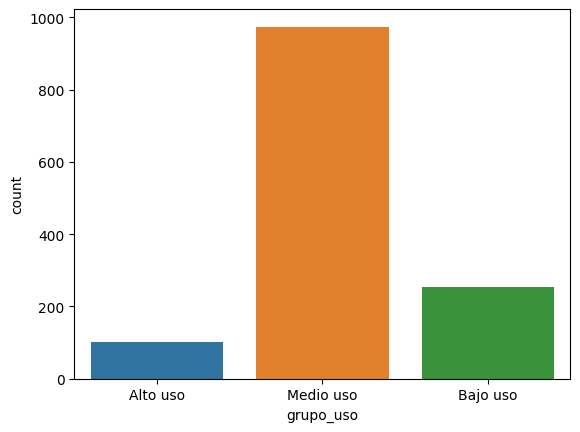

Medio uso    73.233083
Bajo uso     19.172932
Alto uso      7.593985
Name: grupo_uso, dtype: float64
1330


In [57]:
# Visualización de los segmentos por uso
sns.countplot(data = user_profile, x = "grupo_uso")

plt.show()
print (user_profile["grupo_uso"].value_counts()/1330 * 100)
print (user_profile["grupo_uso"].count())

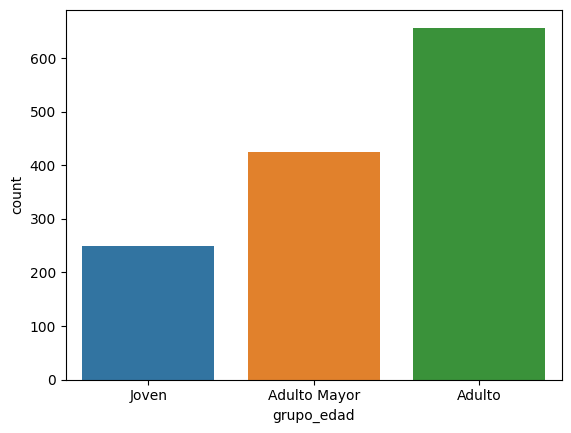

Adulto          49.398496
Adulto Mayor    31.879699
Joven           18.721805
Name: grupo_edad, dtype: float64
1330


In [56]:
# Visualización de los segmentos por edad

sns.countplot(data = user_profile, x = "grupo_edad")


plt.show()
print (user_profile["grupo_edad"].value_counts()/1330 * 100)
print (user_profile["grupo_edad"].count())



---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:** 
- ¿Qué problemas tenían originalmemte los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban?
            Para el caso de usuarios:
                - Tenemos la columna de city con un 11% de valores nulos, por lo cual recomendaría que se dejarán de esta manera ya que no fue necesario segmentar a los clientes por ciudad, también tenía sentinels que fueron convertidos a nulos
                - Y tenemos también la columna de churn_date con un 88% de información nula lo cual parece correcto puesto que la mayoría de la información es de clientes activos, esta columna definitivamente se queda así.
            
            Para el caso de la tabla de usage:
                - Tenemos la columna de date con .25% de nulos, la muestra es muy pequeña por lo cual recomiendo dejarla de esta manera.
                - Tenemos también la columna de duration con un 55%  y de lenght con un 44% de nulos, se verificó que esta información es un tipo MAR por lo que esta correcta la información de esta manera.
            
            - La columna age, tenía valores imposibles por lo que se uso la mediana para rellenar esa información.
            - La columna date de la tabla usage tenía algunos valores faltantes .00125 por lo que no se consideraron significativos
            - La columna regdate de la tabla users tenía valores improbables del año 2026 que se remplazaron por nulos.

- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?

- La mayoria de los usuarios se identifican en el grupo de los adultos es decir usuarios entre 30 y 59 años, los adultos mayores también reprsentan la segunda muestra más importante de los datos.
- Usan su plan de telefonía para haver entre 5 y 9 llamadas y mesales (uso medio).


- 
- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?

- El grupo de los adultos, ya que representa el 49% de los usuarios, después el grupo de los adultos que representa el 31%.
- También el grupo de medio uso que representae el 79% de los clientes 


- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?
- Se observaron usuarios con consumos de aproximadamente 120 a 160 minutos, muy por encima de la mayoría de los clientes, que se concentran por debajo de los 40 minutos, representan los outliers más evidente.
- Existen algunos usuarios con 10 a 13 llamadas, mientras que la mayoría realiza entre 3 y 6 llamadas
- Se identificaron usuarios con 11 a 16 mensajes, cuando la mayor parte de la población envía entre 4 y 8 mensajes



- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?

- Mantener los planes de uso medio, ya que representa la mayor parte de los clientes:
Mantener  los planes orientados a usuarios de uso medio, ya que este segmento representa el 79% de los clientes y constituye el principal mercado, por ende este grupo representa la fuente importante de ingresos
Se recomienda ofrecer algún beneficios adicionales,como descuentos por permanencia, programas de recompensas o promociones exclusivas para clientes frecuentes.
- Crear un plan para incrementar el crecimiento de los usuarios del grupo joven
Es una oportunidad para captar a nuevos clientes y fortalecer estes segmento , podría ser ofrecer algún beneficio extra enfocado al uso de redes o aplicaciones de mensajería como whatsapp.
- Diseñar un plan premium oro:
Para aquellos usuarios que están dentro de los outliers , ofrecer un plan con más ventajas que tenga mas minutos y llamadas y algún beneficio exclusivo, se tendría que verificar primero si perciben alguna limitación con su plan actual y que tipo de llamadas y mensajes realizan, por ejenplo si están viviendo en el extranjero y hablan con sus familia, algún tipo de descuento familiar, de esta manera se retendría a estos clientes y se podría agregar a otros miembros de la familia.




✍️ **Escribe aquí tu análisis ejecutivo:**

### Análisis ejecutivo

⚠️ **Problemas detectados en los datos**
- Se identificaron valores atípicos (outliers) en las variables de cantidad de llamadas, cantidad de mensajes y minutos de llamada, correspondientes a usuarios con niveles de consumo significativamente superiores al promedio.
Las distribuciones de llamadas, mensajes y minutos presentan sesgo a la derecha, lo que indica que una proporción de usuarios concentra una parte importante del uso del servicio.

🔍 **Segmentos por Edad**
Los adultos (30 a 59 años) constituyen el segmento más numeroso de la base de clientes (49%).
Los adultos mayores (60 años o más) representan el segundo grupo más importante (31%), 
Los jóvenes (menores de 30 años) conforman el segmento menos numeroso (18%) 


📊 **Segmentos por Nivel de Uso**
El segmento de uso medio es el predominante, concentrando aproximadamente el 79% de los clientes,
Los segmentos de bajo uso representan el 19% de los usuarios
y alto uso representan una porción menor de usuarios (7%)


➡️ Esto sugiere que ...


💡 **Recomendaciones**
Mantener y fortalecer los planes orientados a usuarios de uso medio, incorporando beneficios que permitan conservar a este segmento.
Desarrollar estrategias específicas para captar más usuarios jóvenes.
Crear beneficios exclusivos para clientes de alto uso y aquellos que se encuentran en los outliers.

Lo anterios con el objetivo de:
- mantener a los cleintes que ya se tienen
- premiar su fidelidad
- captar nuevos mercados como la sección de clientes jovenes.

---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---

Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.
---

Link a repositorio público del proyecto: `LINK a tu repo aquí`